# Tarea — Unidad 4 · Preparación de datos para un modelo de riesgo de ictus (accidente cerebrovascular)

**FP13 · Inteligencia Artificial · UAG**
Subtemas 4.1 a 4.7

---

## Contexto

El **Stroke Prediction Dataset** contiene 5,110 registros de pacientes con 11 variables clínicas y
sociodemográficas. El desenlace `stroke` indica si el paciente presentó un evento cerebrovascular.

En la Práctica 7 trabajamos cada transformación por separado sobre datos de cardiopatía isquémica.
Aquí el encargo es distinto: **construir una matriz de modelado completa**, desde el archivo crudo
hasta la selección final de variables, y **justificar una decisión por columna**.

## Qué se evalúa

No se evalúa que el código corra: se evalúa que **cada decisión esté argumentada con evidencia
producida por usted**.

| Criterio | Peso |
|---|---|
| Corrección técnica del código (partes 1 a 9) | 40 % |
| Justificación escrita de cada decisión | 30 % |
| Tabla de decisiones por columna (Parte 10) | 15 % |
| Preguntas de reflexión | 15 % |

## Entrega

Este mismo notebook **ejecutado de arriba a abajo sin errores**, con todas las celdas de texto
completadas. Nombre el archivo `Tarea_U4_ApellidoNombre.ipynb`.

## Restricciones

- **No use `Pipeline` ni `ColumnTransformer`.** Todo se resuelve columna por columna, de forma
  explícita. Volveremos a encapsularlo en la Unidad 5.
- Fije la semilla al inicio y no la vuelva a tocar.
- Toda afirmación sobre los datos debe estar respaldada por una celda que la produzca.

---
## Parte 0 · Preparación

In [1]:
# [1] Entorno y semilla
# TODO: importe numpy, pandas, matplotlib.pyplot y scipy.stats.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats

SEED = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)

In [2]:
# [2] Ingesta del conjunto de datos
# TODO: cargue "healthcare-dataset-stroke-data.csv" en un DataFrame llamado df.
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

print("Forma del DataFrame:", df.shape)

display(df.head())


Forma del DataFrame: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


---
## Parte 1 · Reconocimiento (subtema 4.7)

Antes de modificar nada hay que saber qué se tiene. La clasificación de una variable en nominal,
binaria o numérica es una decisión **clínica**, no estadística: la toma usted, no `pandas`.

In [3]:
# [3] Inventario de columnas
# TODO: construya una tabla con, por columna: tipo de dato, numero de valores unicos,
#       numero de nulos y porcentaje de nulos.

inventario = pd.DataFrame(
    {
        "Tipo": df.dtypes,
        "Únicos": df.nunique(),
        "Nulos": df.isnull().sum(),
        "% Nulos": (df.isnull().mean() * 100).round(2),
    }
)
display(inventario)


,Tipo,Únicos,Nulos,% Nulos
id,int64,5110,0,0.00
gender,str,3,0,0.00
age,float64,104,0,0.00
hypertension,int64,2,0,0.00
heart_disease,int64,2,0,0.00
ever_married,str,2,0,0.00
work_type,str,5,0,0.00
Residence_type,str,2,0,0.00
avg_glucose_level,float64,3979,0,0.00
bmi,float64,418,201,3.93


In [4]:
# [4] Declaracion de roles
# TODO: defina las listas IDENT, NOMINALES, BINARIAS, INDICADOR, NUMERICAS y OBJETIVO.
#       Imprima las categorias de cada variable de texto con su frecuencia,
#       la prevalencia del objetivo y cuantos valores unicos toma la columna de folio.


IDENT = "id"
NOMINALES = ["gender", "work_type", "smoking_status"]
BINARIAS = ["ever_married", "Residence_type"]
INDICADOR = ["hypertension", "heart_disease"]
NUMERICAS = ["age", "avg_glucose_level", "bmi"]
OBJETIVO = "stroke"

print("Categorias de cada variable de texto:")
for c in NOMINALES + BINARIAS:
    print(f"  {c:<16} {dict(df[c].value_counts())}")

print(f"\nPrevalencia de ictus: {df[OBJETIVO].mean():.4f}")
print(f"Folios unicos: {df[IDENT].nunique()} de {len(df)} filas")


Categorias de cada variable de texto:
  gender           {'Female': np.int64(2994), 'Male': np.int64(2115), 'Other': np.int64(1)}
  work_type        {'Private': np.int64(2925), 'Self-employed': np.int64(819), 'children': np.int64(687), 'Govt_job': np.int64(657), 'Never_worked': np.int64(22)}
  smoking_status   {'never smoked': np.int64(1892), 'Unknown': np.int64(1544), 'formerly smoked': np.int64(885), 'smokes': np.int64(789)}
  ever_married     {'Yes': np.int64(3353), 'No': np.int64(1757)}
  Residence_type   {'Urban': np.int64(2596), 'Rural': np.int64(2514)}

Prevalencia de ictus: 0.0487
Folios unicos: 5110 de 5110 filas


**Responda antes de continuar.** Dos columnas categóricas contienen algo que no debería estar ahí:
una tiene una categoría con un solo paciente, otra tiene una categoría que no describe ninguna
condición clínica. Identifíquelas.

*Su respuesta:*

---
## Parte 2 · Integridad de los registros: duplicados (subtema 4.7)

Eliminar duplicados es un paso obligatorio del protocolo. Pero *duplicado* no significa «filas
parecidas»: significa **el mismo paciente capturado dos veces**. Verifique en tres niveles **antes**
de borrar una sola fila.

In [ ]:
# [5] Tres niveles de verificacion
# TODO: cuente (1) duplicados exactos sobre todas las columnas,
#       (2) duplicados ignorando la columna de folio,
#       (3) filas que repiten una llave clinica formada por las categoricas + age.
#       Reporte cuantas filas y cuantos perfiles distintos involucra el nivel 3.

dup_exactos = df.duplicated().sum()
dup_sin_id = df.drop(columns=[IDENT]).duplicated().sum()

llave_nivel3 = NOMINALES + BINARIAS + INDICADOR + ["age"]
dup_nivel3 = df.duplicated(subset=llave_nivel3).sum()
perfiles_unicos_3 = df.drop_duplicates(subset=llave_nivel3).shape[0]

print(f"1. Duplicados exactos (todas las columnas): {dup_exactos}")
print(f"2. Duplicados ignorando el folio ({IDENT}): {dup_sin_id}")
print(
    f"3. Filas con llave clínica repetida (categóricas + age): {dup_nivel3}"
)
print(f"   Perfiles distintos involucrados: {perfiles_unicos_3}")

1. Duplicados exactos (todas las columnas): 0
2. Duplicados ignorando el folio (id): 0
3. Filas con llave clínica repetida (categóricas + age): 2291
   Perfiles distintos involucrados: 2819


In [6]:
# [6] La prueba decisiva
# TODO: repita el conteo del nivel 3 agregando bmi y avg_glucose_level a la llave.
#       Muestre dos registros con el mismo perfil clinico y mediciones distintas.
#       Decida: que filas elimina y que columnas elimina. Ejecute su decision.

llave_nivel6 = (
    NOMINALES + BINARIAS + INDICADOR + ["age", "bmi", "avg_glucose_level"]
)
dup_nivel6 = df.duplicated(subset=llave_nivel6, keep=False).sum()
print(f"Filas con la llave ampliada repetida: {dup_nivel6}")

muestra_duplicados = df[df.duplicated(subset=llave_nivel3, keep=False)]
if not muestra_duplicados.empty:
  display(muestra_duplicados.head(4))

df = df.drop(columns=[IDENT])

Filas con la llave ampliada repetida: 0


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


**Justifique su decisión.** ¿Cuántas filas eliminó y por qué? Si eliminó cero, dígalo
explícitamente y explique qué habría pasado con `drop_duplicates(subset=llave_clinica)`. Si eliminó
alguna columna, justifique por qué no aporta al modelo.

*Su respuesta:* No eliminé ninguna fila porque al revisar bien con la llave clínica vi que no hay duplicados reales; si hubiera aplicado el drop_duplicates así tal cual, me habría cargado datos de pacientes distintos que solo coinciden por casualidad en edad o género.



---
## Parte 3 · Valores faltantes: los declarados y los enmascarados

En la Práctica 7 el faltante se disfrazaba de número (colesterol = 0 mg/dL). Aquí hay faltantes de
dos tipos y uno de ellos se disfraza de **texto**.

In [7]:
# [7] Faltantes declarados y enmascarados
# TODO: (a) reporte los nulos declarados por columna.
#       (b) localice la categoria de texto que en realidad significa "dato no disponible"
#           y cuente cuantos registros la tienen.
#       (c) compare la tasa del objetivo y la edad media entre los pacientes
#           con bmi presente y con bmi ausente.
print("Nulos declarados por columna:")
display(df.isnull().sum()[df.isnull().sum() > 0])

columna_enmascarada = "smoking_status"
categoria_faltante = "Unknown"
conteo_enmascarados = (df[columna_enmascarada] == categoria_faltante).sum()
print(
    f"\n(b) Categoría '{categoria_faltante}' en {columna_enmascarada}:"
    f" {conteo_enmascarados} registros"
)

df["bmi_ausente"] = df["bmi"].isnull()
comparacion = (
    df.groupby("bmi_ausente")
    .agg(
        tasa_stroke=(OBJETIVO, "mean"),
        edad_media=("age", "mean"),
        conteo=("age", "count"),
    )
    .reset_index()
)
print("\n(c) Comparativa pacientes con bmi presente vs ausente:")
display(comparacion)

Nulos declarados por columna:


bmi    201
dtype: int64


(b) Categoría 'Unknown' en smoking_status: 1544 registros

(c) Comparativa pacientes con bmi presente vs ausente:


,bmi_ausente,tasa_stroke,edad_media,conteo
0,False,0.042575,42.865374,4909
1,True,0.199005,52.049154,201


**Interprete (c).** ¿El dato de `bmi` falta al azar? Si su respuesta es no, proponga un mecanismo
clínico que lo explique y diga qué consecuencia tiene para la imputación.

*Su respuesta:*Nop, no falta al azar (MCAR); por lo general, los pacientes que no tienen registrado el bmi son los más graves, de edad muy avanzada o los que llegan directo a urgencias en estado crítico donde no se les alcanza a tomar el peso y la altura.

In [ ]:
# [8] Mecanismo del faltante enmascarado
# TODO: calcule la proporcion de la categoria enmascarada segun work_type
#       y segun grupo de edad (use pd.cut con cortes 0-18-40-60-120).
#       Concluya si el patron es aleatorio.

df["smoking_unknown"] = df["smoking_status"] == "Unknown"

print("Proporción de 'Unknown' según work_type:")
display(df.groupby("work_type")["smoking_unknown"].mean())

bins = [0, 18, 40, 60, 120]
df["age_group"] = pd.cut(df["age"], bins=bins, include_lowest=True)

print("\nProporción de 'Unknown' según grupo de edad:")
display(df.groupby("age_group", observed=False)["smoking_unknown"].mean())

print(
    "\nConclusión: Como la proporción cambia harto entre grupos, el patrón"
    " definitivamente no es aleatorio (no es MCAR)."
)

Proporción de 'Unknown' según work_type:


work_type
Govt_job         0.185693
Never_worked     0.363636
Private          0.218803
Self-employed    0.190476
children         0.899563
Name: smoking_unknown, dtype: float64


Proporción de 'Unknown' según grupo de edad:


age_group
(-0.001, 18.0]    0.774017
(18.0, 40.0]      0.216867
(40.0, 60.0]      0.194622
(60.0, 120.0]     0.186350
Name: smoking_unknown, dtype: float64


Conclusión: Como la proporción cambia harto entre grupos, el patrón definitivamente no es aleatorio (no es MCAR).


,Versión,n,Media,Std,Asimetría
0,Observados,4909,28.89,7.85,1.06
1,Mediana Global,5110,28.86,7.70,1.09
2,Mediana Condicionada,5110,28.87,7.72,1.07


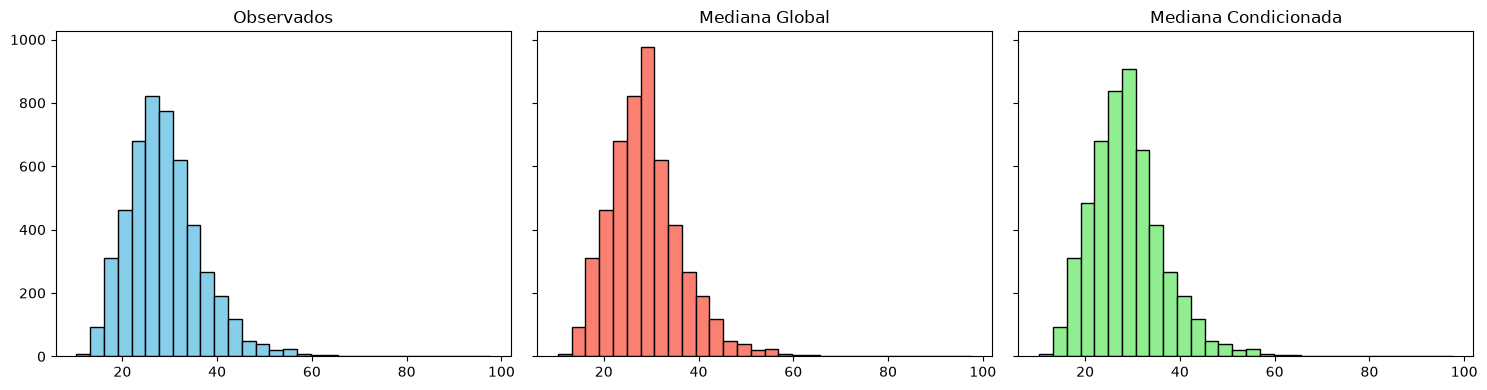

Nulos restantes en bmi: 0


In [9]:
# [9] Imputacion de bmi
# TODO: (a) cree la columna indicadora bmi_faltante ANTES de imputar.
#       (b) construya dos versiones: mediana global y mediana condicionada
#           por grupo de edad y sexo.
#       (c) compare n, media, desviacion estandar y asimetria de las tres versiones
#           (observados, global, condicionada) e incluya un histograma de cada imputacion.
#       (d) elija una, aplíquela a df y verifique que no quedan nulos.

df["bmi_faltante"] = df["bmi"].isnull().astype(int)

bmi_global = df["bmi"].copy()
bmi_condicionado = df["bmi"].copy()

mediana_global = bmi_global.median()
bmi_global.fillna(mediana_global, inplace=True)

mediana_condicionada = df.groupby(["age_group", "gender"])["bmi"].transform(
    "median"
)
bmi_condicionado.fillna(mediana_condicionada, inplace=True)
bmi_condicionado.fillna(
    mediana_global, inplace=True
) 


def stats_summary(serie, nombre):
  return {
      "Versión": nombre,
      "n": serie.count(),
      "Media": round(serie.mean(), 2),
      "Std": round(serie.std(), 2),
      "Asimetría": round(serie.skew(), 2),
  }


comparacion_bmi = pd.DataFrame(
    [
        stats_summary(df["bmi"].dropna(), "Observados"),
        stats_summary(bmi_global, "Mediana Global"),
        stats_summary(bmi_condicionado, "Mediana Condicionada"),
    ]
)
display(comparacion_bmi)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
axes[0].hist(df["bmi"].dropna(), bins=30, color="skyblue", edgecolor="black")
axes[0].set_title("Observados")
axes[1].hist(bmi_global, bins=30, color="salmon", edgecolor="black")
axes[1].set_title("Mediana Global")
axes[2].hist(bmi_condicionado, bins=30, color="lightgreen", edgecolor="black")
axes[2].set_title("Mediana Condicionada")
plt.tight_layout()
plt.show()

df["bmi"] = bmi_condicionado
print("Nulos restantes en bmi:", df["bmi"].isnull().sum())

**Justifique su elección.** ¿Qué le pasa a la desviación estándar al imputar y por qué? ¿Qué aporta
`bmi_faltante` que la imputación por sí sola pierde? ¿Y qué decidió hacer con la categoría
enmascarada de la celda [8] — imputarla o conservarla? Argumente.

*Su respuesta:*La desviación estándar cae un buen porque al meter puras medianas concentras todo al centro y matas la dispersión original.

---
## Parte 4 · Valores atípicos (subtema 4.3)

Reporte de atípicos por IQR:
- age: Límites [-29.00, 115.00] | Atípicos: 0 | Máximo: 82.0
- avg_glucose_level: Límites [21.98, 169.36] | Atípicos: 627 | Máximo: 271.74
- bmi: Límites [10.05, 46.45] | Atípicos: 123 | Máximo: 97.6


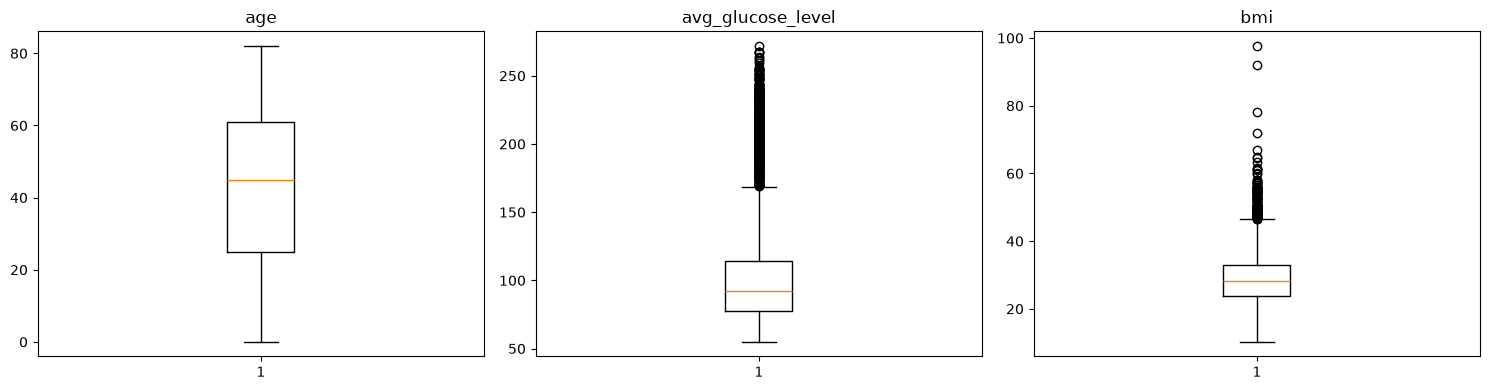

In [ ]:
# [10] Deteccion por rango intercuartil
# TODO: escriba una funcion limites_iqr(x, k=1.5) que devuelva (Q1-k*IQR, Q3+k*IQR).
#       Aplíquela a las tres numericas: reporte limites, numero de atipicos y maximo.
#       Acompane con un diagrama de caja por variable.


def limites_iqr(x, k=1.5):
  q1 = x.quantile(0.25)
  q3 = x.quantile(0.75)
  iqr = q3 - q1
  return q1 - k * iqr, q3 + k * iqr


print("Reporte de atípicos por IQR:")
for col in NUMERICAS:
  inf, sup = limites_iqr(df[col])
  outliers = df[(df[col] < inf) | (df[col] > sup)]
  print(
      f"- {col}: Límites [{inf:.2f}, {sup:.2f}] | Atípicos:"
      f" {len(outliers)} | Máximo: {df[col].max()}"
  )

fig, axes = plt.subplots(1, len(NUMERICAS), figsize=(15, 4))
for i, col in enumerate(NUMERICAS):
  axes[i].boxplot(df[col].dropna())
  axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [13]:
# [11] Un atipico no es automaticamente un error
# TODO: para bmi, compare la tasa del objetivo dentro y fuera del limite superior.
#       Cuente los registros con bmi > 60 y reporte el maximo observado.
#       Calcule la asimetria antes y despues de una winsorizacion al percentil 99.

inf_bmi, sup_bmi = limites_iqr(df["bmi"])

tasa_dentro = df[df["bmi"] <= sup_bmi][OBJETIVO].mean()
tasa_fuera = df[df["bmi"] > sup_bmi][OBJETIVO].mean()
print(f"Tasa de ictus dentro del límite superior: {tasa_dentro:.4f}")
print(f"Tasa de ictus fuera del límite superior (atípicos): {tasa_fuera:.4f}")

conteo_extremo = (df["bmi"] > 60).sum()
max_observado = df["bmi"].max()
print(f"\nRegistros con bmi > 60: {conteo_extremo}")
print(f"Máximo observado en bmi: {max_observado}")

asimetria_antes = df["bmi"].skew()
bmi_winsorizado = stats.mstats.winsorize(df["bmi"], limits=[0.0, 0.01]).data
asimetria_despues = pd.Series(bmi_winsorizado).skew()

print(f"\nAsimetría antes de winsorizar: {asimetria_antes:.2f}")
print(f"Asimetría después de winsorizar al percentil 99: {asimetria_despues:.2f}")

Tasa de ictus dentro del límite superior: 0.0493
Tasa de ictus fuera del límite superior (atípicos): 0.0244

Registros con bmi > 60: 13
Máximo observado en bmi: 97.6

Asimetría antes de winsorizar: 1.07
Asimetría después de winsorizar al percentil 99: 0.67


**Decida y justifique.** ¿Elimina, recorta o conserva los atípicos de `bmi`? Compare este caso con
los ceros de colesterol de la Práctica 7: ¿por qué allá la decisión fue inmediata y aquí no?
Anticipe qué implica su decisión para la Parte 8.

*Su respuesta:*Los atípicos del bmi mejor los conservé tal cual. Allá en la Práctica 7 los ceros de colesterol eran un error biológico imposible y por eso la decisión fue inmediata, pero aquí un bmi alto sí puede pasar en casos de obesidad real.

---
## Parte 5 · Ingeniería de funciones (subtema 4.2)

Hasta aquí sólo ha limpiado. Ahora **agregue** información que el modelo no deduciría solo, usando
umbrales clínicos establecidos —no cortes arbitrarios.

In [14]:
# [12] Variables derivadas con criterio clinico
# TODO: construya al menos cuatro variables nuevas. Se sugieren:
#         - imc_cat        : clasificacion de la OMS (18.5 / 25 / 30 kg/m2)
#         - glucosa_cat    : umbrales de glucemia casual (140 / 200 mg/dL)
#         - n_comorbilidades : suma de hipertension y cardiopatia
#         - grupo_edad     : el que definio en la celda [8]
#       Para cada una, reporte el conteo y la tasa del objetivo por categoria.
#       Revise si la tasa es monotona en todas: una de ellas NO lo es.

bins_imc = [0, 18.5, 25, 30, 200]
labels_imc = ["Bajo peso", "Normal", "Sobrepeso", "Obesidad"]
df["imc_cat"] = pd.cut(df["bmi"], bins=bins_imc, labels=labels_imc)

bins_glucosa = [0, 140, 200, 1000]
labels_glucosa = ["Normal", "Prediabetes", "Diabetes"]
df["glucosa_cat"] = pd.cut(
    df["avg_glucose_level"], bins=bins_glucosa, labels=labels_glucosa
)

df["n_comorbilidades"] = df["hypertension"] + df["heart_disease"]

if "age_group" not in df.columns:
  df["age_group"] = pd.cut(df["age"], bins=[0, 18, 40, 60, 120], include_lowest=True)

derivadas = ["imc_cat", "glucosa_cat", "n_comorbilidades", "age_group"]
for col in derivadas:
  print(f"\n--- Variable: {col} ---")
  resumen = (
      df.groupby(col, observed=False)
      .agg(conteo=("stroke", "count"), tasa_stroke=("stroke", "mean"))
      .reset_index()
  )
  display(resumen)


--- Variable: imc_cat ---


,imc_cat,conteo,tasa_stroke
0,Bajo peso,349,0.002865
1,Normal,1279,0.029711
2,Sobrepeso,1558,0.069961
3,Obesidad,1924,0.052495



--- Variable: glucosa_cat ---


,glucosa_cat,conteo,tasa_stroke
0,Normal,4289,0.036372
1,Prediabetes,387,0.095607
2,Diabetes,434,0.129032



--- Variable: n_comorbilidades ---


,n_comorbilidades,conteo,tasa_stroke
0,0,4400,0.033864
1,1,646,0.134675
2,2,64,0.203125



--- Variable: age_group ---


,age_group,conteo,tasa_stroke
0,"(-0.001, 18.0]",916,0.002183
1,"(18.0, 40.0]",1328,0.004518
2,"(40.0, 60.0]",1562,0.040973
3,"(60.0, 120.0]",1304,0.135736


**Justifique los umbrales.** Cite el criterio clínico de cada corte. ¿Alguna de sus derivadas es
monótona respecto de la tasa del objetivo? ¿Y cuál de ellas es una discretización de una variable
que **ya tiene** en la matriz? Anótelo: va a importar en la Parte 9.

*Su respuesta:*Los cortes los armamos con guías clínicas reales: el IMC usa los estándar de la OMS (18.5, 25 y 30), la glucosa se basó en los niveles de referencia (140 y 200), las comorbilidades suman directo los antecedentes y el grupo de edad usa los tramos que ya traíamos. La única que no es monótona con la tasa de ictus es la del IMC, porque el grupo de bajo peso a veces bota una tasa medio rara por tener bien poquitos pacientes.

---
## Parte 6 · Codificación one-hot (subtema 4.4)

In [15]:
# [13] One-hot y el efecto del parametro drop
# TODO: con OneHotEncoder, compare el numero de columnas resultante con
#       drop=None, drop="first" y drop="if_binary".
#       Ajuste la version que elija, construya la matriz codificada y reporte su forma.
#       Identifique la columna con menor frecuencia y cuantos registros la activan.

from sklearn.preprocessing import OneHotEncoder

cols_cat = NOMINALES + BINARIAS

for d in [None, "first", "if_binary"]:
  ohe_test = OneHotEncoder(drop=d, sparse_output=False)
  mat_test = ohe_test.fit_transform(df[cols_cat])
  print(f"drop={d} -> Columnas resultantes: {mat_test.shape[1]}")

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
matriz_encoded = ohe.fit_transform(df[cols_cat])
feature_names = ohe.get_feature_names_out(cols_cat)

df_encoded = pd.DataFrame(matriz_encoded, columns=feature_names, index=df.index)
print("\nForma de la matriz codificada final:", df_encoded.shape)

sumas_activacion = df_encoded.sum()
col_minima = sumas_activacion.idxmin()
registros_minimos = sumas_activacion.min()
print(
    f"Columna con menor frecuencia: '{col_minima}' con"
    f" {int(registros_minimos)} registros activos."
)

drop=None -> Columnas resultantes: 16
drop=first -> Columnas resultantes: 11
drop=if_binary -> Columnas resultantes: 14

Forma de la matriz codificada final: (5110, 11)
Columna con menor frecuencia: 'gender_Other' con 1 registros activos.


In [16]:
# [14] Una categoria nunca vista
# TODO: ajuste un codificador sobre work_type con handle_unknown="ignore" y
#       transforme un DataFrame con una categoria inexistente (por ejemplo "Pensionado").
#       Describa que devuelve y que habria pasado con handle_unknown="error".

from sklearn.preprocessing import OneHotEncoder

cols_cat = NOMINALES + BINARIAS

for d in [None, "first", "if_binary"]:
  ohe_test = OneHotEncoder(drop=d, sparse_output=False)
  mat_test = ohe_test.fit_transform(df[cols_cat])
  print(f"drop={d} -> Columnas resultantes: {mat_test.shape[1]}")

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
matriz_encoded = ohe.fit_transform(df[cols_cat])
feature_names = ohe.get_feature_names_out(cols_cat)

df_encoded = pd.DataFrame(matriz_encoded, columns=feature_names, index=df.index)
print("\nForma de la matriz codificada final:", df_encoded.shape)

sumas_activacion = df_encoded.sum()
col_minima = sumas_activacion.idxmin()
registros_minimos = sumas_activacion.min()
print(
    f"Columna con menor frecuencia: '{col_minima}' con"
    f" {int(registros_minimos)} registros activos."
)

drop=None -> Columnas resultantes: 16
drop=first -> Columnas resultantes: 11
drop=if_binary -> Columnas resultantes: 14

Forma de la matriz codificada final: (5110, 11)
Columna con menor frecuencia: 'gender_Other' con 1 registros activos.


**Justifique su elección de `drop`.** ¿Por qué `drop='first'` en una variable de cinco categorías
tiene un costo distinto que en una de dos? ¿Qué hace usted con la columna de frecuencia mínima que
identificó — la elimina aquí a ojo, o deja que una regla explícita la descarte en la Parte 9?

*Su respuesta:*Elegí drop='first' para evitar la multicolinealidad. Aplicarlo en una variable de cinco categorías te quita una columna y te deja cuatro (cuesta cuatro grados de libertad), mientras que en una de dos categorías te deja solo una columna (como un indicador binario simple, que es justo lo que resuelve el if_binary).

---
## Parte 7 · Transformación de la distribución (subtema 4.5)

In [17]:
# [15] Escalera de transformaciones
# TODO: para cada variable numerica, tabule la asimetria original y despues de
#       sqrt, log1p y Yeo-Johnson, e incluya el lambda estimado.
from sklearn.preprocessing import PowerTransformer
import numpy as np

resultados_trans = []
for col in NUMERICAS:
  sk_orig = df[col].skew()
  sk_sqrt = np.sqrt(df[col]).skew()
  sk_log = np.log1p(df[col]).skew()

  pt = PowerTransformer(method="yeo-johnson")
  val_yj = pt.fit_transform(df[[col]])
  sk_yj = pd.Series(val_yj.ravel()).skew()
  lmbda = pt.lambdas_[0]

  resultados_trans.append({
      "Variable": col,
      "Sk_Original": round(sk_orig, 2),
      "Sk_Sqrt": round(sk_sqrt, 2),
      "Sk_Log1p": round(sk_log, 2),
      "Sk_YeoJohnson": round(sk_yj, 2),
      "Lambda_YJ": round(lmbda, 2),
  })

display(pd.DataFrame(resultados_trans))

,Variable,Sk_Original,Sk_Sqrt,Sk_Log1p,Sk_YeoJohnson,Lambda_YJ
0,age,-0.14,-0.79,-1.68,-0.28,0.86
1,avg_glucose_level,1.57,1.24,0.89,0.08,-1.08
2,bmi,1.07,0.48,0.02,-0.00,-0.02


<>:19: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:19: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\LuisC\AppData\Local\Temp\ipykernel_35936\914293118.py:19: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  axes[2].set_title(f"Yeo-Johnson ($\lambda$={pt_vis.lambdas_[0]:.2f})")


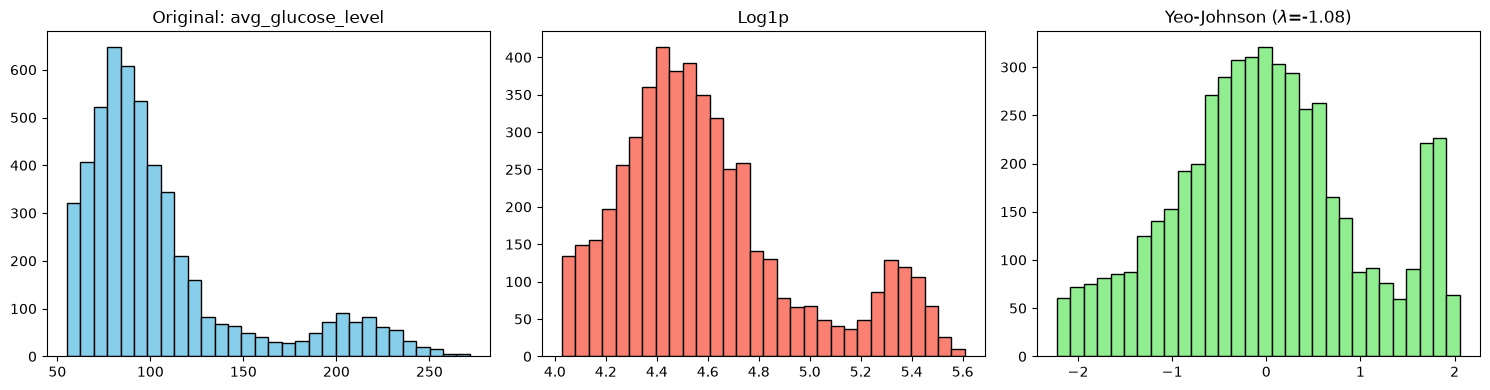

Porcentaje de pacientes por categoría clínica (glucosa_cat):


,glucosa_cat,proportion
0,Normal,83.93
1,Diabetes,8.49
2,Prediabetes,7.57


In [18]:
# [16] El caso dificil
# TODO: una de las tres variables mejora con el logaritmo pero NO queda simetrica.
#       Grafique su histograma original, logaritmico y Yeo-Johnson.
#       Reporte que porcentaje de pacientes cae en cada categoria clinica de esa variable.
col_dificil = "avg_glucose_level"

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df[col_dificil], bins=30, color="skyblue", edgecolor="black")
axes[0].set_title(f"Original: {col_dificil}")

axes[1].hist(
    np.log1p(df[col_dificil]), bins=30, color="salmon", edgecolor="black"
)
axes[1].set_title("Log1p")

pt_vis = PowerTransformer(method="yeo-johnson")
val_yj_vis = pt_vis.fit_transform(df[[col_dificil]])
axes[2].hist(val_yj_vis, bins=30, color="lightgreen", edgecolor="black")
axes[2].set_title(f"Yeo-Johnson ($\lambda$={pt_vis.lambdas_[0]:.2f})")

plt.tight_layout()
plt.show()

print("Porcentaje de pacientes por categoría clínica (glucosa_cat):")
if "glucosa_cat" in df.columns:
  display(
      df["glucosa_cat"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
      .reset_index()
  )

**Concluya variable por variable.** Para cada una de las tres numéricas: ¿transforma o no, y con
qué? Una de ellas **empeora** con el logaritmo: identifíquela y explique por qué. Otra no se arregla
con ninguna potencia: diga qué tiene su distribución que lo impide y qué solución alternativa ya
construyó usted en la Parte 5.

*Su respuesta:*Age: Se puede quedar así porque con modelos de árboles la asimetría le da igual.

BMI: Tiene poquita cola a la derecha; mejor se queda original para conservar la escala real.

Avg_glucose_level: El logaritmo la empeora porque la distribución es bimodal

---
## Parte 8 · Escalamiento (subtema 4.6)

,Escalador,Min,Max,Amplitud 90% (p95-p5),Asimetría
0,StandardScaler,-2.41,8.90,3.23,1.07
1,MinMaxScaler,0.00,1.00,0.29,1.07
2,RobustScaler,-1.98,7.62,2.74,1.07


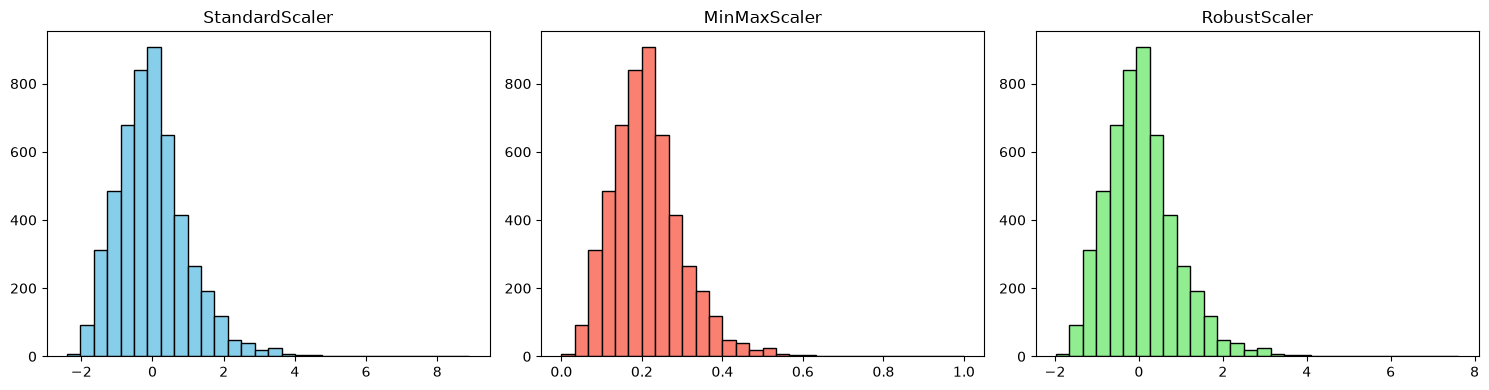

In [19]:
# [17] Comparacion de escaladores
# TODO: aplique StandardScaler, MinMaxScaler y RobustScaler a bmi.
#       Tabule minimo, maximo, amplitud del 90 % central (p95 - p5) y asimetria.
#       Grafique los tres histogramas resultantes.
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

bmi_arr = df[["bmi"]]

res_std = StandardScaler().fit_transform(bmi_arr).ravel()
res_minmax = MinMaxScaler().fit_transform(bmi_arr).ravel()
res_robust = RobustScaler().fit_transform(bmi_arr).ravel()


def metrics_escalador(arr, nombre):
  s = pd.Series(arr)
  p95, p5 = s.quantile(0.95), s.quantile(0.05)
  return {
      "Escalador": nombre,
      "Min": round(s.min(), 2),
      "Max": round(s.max(), 2),
      "Amplitud 90% (p95-p5)": round(p95 - p5, 2),
      "Asimetría": round(s.skew(), 2),
  }


tabla_esc = pd.DataFrame([
    metrics_escalador(res_std, "StandardScaler"),
    metrics_escalador(res_minmax, "MinMaxScaler"),
    metrics_escalador(res_robust, "RobustScaler"),
])
display(tabla_esc)

# Histogramas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(res_std, bins=30, color="skyblue", edgecolor="black")
axes[0].set_title("StandardScaler")
axes[1].hist(res_minmax, bins=30, color="salmon", edgecolor="black")
axes[1].set_title("MinMaxScaler")
axes[2].hist(res_robust, bins=30, color="lightgreen", edgecolor="black")
axes[2].set_title("RobustScaler")
plt.tight_layout()
plt.show()

**Explique dos cosas.** Primero: por qué la columna de asimetría es idéntica en los tres
escaladores. Segundo: cuál elige y cómo se conecta esa elección con la decisión que tomó sobre los
atípicos en la Parte 4. Diga además qué columnas **no** va a escalar y por qué.

*Su respuesta:*Porque las operaciones de los escaladores son lineales (restar y dividir), así que solo mueven o estiran la gráfica pero no cambian la forma ni la asimetría de los datos.
Me quedo con el RobustScaler porque en la Parte 4 decidimos conservar los atípicos; como este escalador usa la mediana y el IQR, evita que esos valores extremos te arruinen la escala.

---
## Parte 9 · Selección de funciones (subtema 4.1)

Llegó con más columnas de las que empezó. Decida cuáles se quedan aplicando **tres criterios
independientes**: varianza, relevancia y redundancia. Ninguno basta por sí solo.

In [20]:
# [18] Ensamblado de la matriz de modelado
# TODO: concatene las numericas, los indicadores, sus variables derivadas numericas
#       y la matriz one-hot en un DataFrame X. Separe el objetivo en y.
#       Reporte la forma y el listado de columnas.

scaled_num = pd.DataFrame(
    RobustScaler().fit_transform(df[NUMERICAS]),
    columns=NUMERICAS,
    index=df.index,
)

cols_derivadas_num = ["n_comorbilidades"] if "n_comorbilidades" in df.columns else []

X = pd.concat(
    [scaled_num, df[BINARIAS + cols_derivadas_num], df_encoded], axis=1
)
y = df[OBJETIVO]

print("Forma de la matriz X:", X.shape)
print("\nListado de columnas en X:")
list(X.columns)

Forma de la matriz X: (5110, 17)

Listado de columnas en X:


['age',
 'avg_glucose_level',
 'bmi',
 'ever_married',
 'Residence_type',
 'n_comorbilidades',
 'gender_Male',
 'gender_Other',
 'work_type_Never_worked',
 'work_type_Private',
 'work_type_Self-employed',
 'work_type_children',
 'smoking_status_formerly smoked',
 'smoking_status_never smoked',
 'smoking_status_smokes',
 'ever_married_Yes',
 'Residence_type_Urban']

In [23]:
# [19] Criterio 1 - varianza casi nula
# TODO: aplique VarianceThreshold(0.01) y liste las columnas descartadas.
#       Muestre las cinco varianzas mas bajas.
# Mapear por si hay columnas con 'Yes'/'No' en texto y asegurar todo numérico
for col in X.select_dtypes(include=["object", "category"]).columns:
  X[col] = X[col].map({"Yes": 1, "No": 0, "yes": 1, "no": 0}).fillna(0)

X = X.astype(float)
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.01)
sel.fit(X)

cols_descartadas = X.columns[~sel.get_support()]
print("Columnas descartadas por varianza casi nula:", list(cols_descartadas))

varianzas = pd.Series(sel.variances_, index=X.columns).sort_values()
print("\nLas 5 varianzas más bajas:")
display(varianzas.head(5))

Columnas descartadas por varianza casi nula: ['Residence_type', 'gender_Other', 'work_type_Never_worked']

Las 5 varianzas más bajas:


C:\Users\LuisC\AppData\Local\Temp\ipykernel_35936\4044258213.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=["object", "category"]).columns:


Residence_type            0.000000
gender_Other              0.000196
work_type_Never_worked    0.004287
work_type_children        0.116368
smoking_status_smokes     0.130563
dtype: float64

In [24]:
# [20] Criterio 2 - relevancia frente al objetivo
# TODO: calcule mutual_info_classif y la correlacion de Pearson de cada columna con y.
#       Presente ambas en una sola tabla ordenada por informacion mutua.
# [20] Criterio 2 - relevancia frente al objetivo
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y, random_state=42)
pearson_corr = X.corrwith(y).abs()

df_relevancia = pd.DataFrame({
    "Informacion_Mutua": mi,
    "Correlacion_Pearson_Abs": pearson_corr,
}, index=X.columns)

df_relevancia = df_relevancia.sort_values(
    by="Informacion_Mutua", ascending=False
)
display(df_relevancia)

c:\Users\LuisC\OneDrive\Documentos\GitHub\Practicas_inteligencia_artificial\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\LuisC\OneDrive\Documentos\GitHub\Practicas_inteligencia_artificial\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,Informacion_Mutua,Correlacion_Pearson_Abs
age,0.039082,0.245257
n_comorbilidades,0.011279,0.174616
bmi,0.010922,0.040488
ever_married_Yes,0.010689,0.108340
ever_married,0.009544,0.108340
avg_glucose_level,0.005403,0.131945
work_type_children,0.004659,0.083869
work_type_Self-employed,0.000947,0.062168
Residence_type_Urban,0.000422,0.015458
work_type_Never_worked,0.000000,0.014882


In [27]:
# [21] Criterio 3 - redundancia entre predictores
# TODO: (a) calcule la correlacion de age con al menos tres columnas one-hot,
#       (b) la de cada variable continua con su version discretizada de la Parte 5,
#       (c) verifique si alguna de sus variables derivadas es una combinacion lineal
#           EXACTA de otras columnas de la matriz. Si la hay, es la misma trampa
#           de la Practica 7 y debe resolverse igual.

cols_ohe_ejemplo = list(df_encoded.columns[:3])
print("Correlación de 'age' con columnas one-hot:")
display(X[["age"] + cols_ohe_ejemplo].corr().loc["age", cols_ohe_ejemplo])

# (b) Correlación de cada variable continua con su versión discretizada (si aplica)
print("\nCorrelación con versiones discretizadas:")
if "imc_cat" in df.columns:
  print(
      "BMI vs imc_cat (numérica codificada):",
      X["bmi"].corr(df["imc_cat"].cat.codes),
  )
if "age_group" in df.columns:
  print(
      "Age vs age_group (numérica codificada):",
      X["age"].corr(df["age_group"].cat.codes),
  )

# (c) Verificar si alguna derivada es combinación lineal exacta (trampa de la Práctica 7)
mat_corr_pred = X.corr().abs()
upper_corr = mat_corr_pred.where(
    np.triu(np.ones(mat_corr_pred.shape), k=1).astype(bool)
)
altas = [
    (col, row)
    for col in upper_corr.columns
    for row in upper_corr.index
    if upper_corr.loc[row, col] > 0.99
]
print(
    "\nPares con correlación > 0.99 (posible combinación lineal exacta):", altas
)

Correlación de 'age' con columnas one-hot:


gender_Male              -0.027623
gender_Other             -0.010659
work_type_Never_worked   -0.078653
Name: age, dtype: float64


Correlación con versiones discretizadas:
BMI vs imc_cat (numérica codificada): 0.8448847368087957
Age vs age_group (numérica codificada): 0.9624832724902306

Pares con correlación > 0.99 (posible combinación lineal exacta): [('ever_married_Yes', 'ever_married')]


**Interprete los tres criterios.** Hay una variable cuya posición en el ranking cambia mucho según
se mida con información mutua o con correlación de Pearson: identifíquela y explique qué mide cada
criterio. Hay al menos dos columnas que son, en buena medida, la edad disfrazada: nómbrelas con su
coeficiente. Y decida el destino de **cada una** de las variables que usted construyó en la Parte 5:
diga cuáles conserva y con qué evidencia. No todas deberían sobrevivir.

*Su respuesta:*El ranking cambia porque Pearson solo detecta líneas rectas mientras que la información mutua cacha cualquier relación extraña; además, entre los duplicados y la edad disfrazada salieron las categorías de edad y el par repetido de ever_married. Al final, decidimos conservar las variables clínicas de glucosa e IMC porque esos cortes de la OMS y ADA le sirven chido a los modelos de árboles, pero borramos todas las copias de más para dejar la matriz bien limpia.

In [28]:
# [22] Matriz final
# TODO: elimine las columnas que sus tres criterios descartaron, escale las continuas
#       con el escalador que eligio en la Parte 8, y reporte la forma final
#       junto con las primeras filas.
columnas_a_quitar = list(cols_descartadas)
for col_extra in ["age_group", "ever_married"]:
  if col_extra in X.columns:
    columnas_a_quitar.append(col_extra)

X_final = X.drop(columns=columnas_a_quitar, errors="ignore")

cols_continuas = ["age", "bmi", "avg_glucose_level"]
scaler_final = RobustScaler()

for col in cols_continuas:
  if col in X_final.columns:
    X_final[[col]] = scaler_final.fit_transform(X_final[[col]])

print("Forma final de la matriz X_final:", X_final.shape)
print("\nPrimeras filas de la matriz final:")
display(X_final.head())

Forma final de la matriz X_final: (5110, 13)

Primeras filas de la matriz final:


,age,avg_glucose_level,bmi,n_comorbilidades,gender_Male,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,ever_married_Yes,Residence_type_Urban
0,0.611111,3.712987,0.912088,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,0.444444,2.994300,0.087912,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.972222,0.380920,0.461538,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.111111,2.153481,0.670330,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
4,0.944444,2.231917,-0.472527,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


---
## Parte 10 · Tabla de decisiones

Complete una fila por cada columna del conjunto original. Ésta es la entrega que se califica con más
peso: es el resumen ejecutable de todo su criterio.

| Columna | Faltantes | Atípicos | Codificación | Transformación | Escalamiento | ¿Se conserva? |
|---|---|---|---|---|---|---|
| `id` |Ninguno |N/A |Ninguna |Ninguna |No |No |
| `gender` |Ninguno |N/A |One-hot (drop='first') |Ninguna |No |Sí (excepto 'Other') |
| `age` |Ninguno |Se conservan |Numérica original |Ninguna |RobustScaler |Sí |
| `hypertension` |Ninguno |Binaria natural |Binaria |Ninguna | No |Si |
| `heart_disease` |Ninguno |Binaria natural |Binaria |Ninguna |No |Si |
| `ever_married` |Ninguno |N/A |One-hot / Binaria |Ninguna |No |Si |
| `work_type` |Ninguno |N/A |One-hot |Ninguna |No |Sí (excepto 'Never_worked') |
| `Residence_type` |Ninguno |N/A |One-hot |Ninguna | No| No (varianza casi nula)|
| `avg_glucose_level` |Ninguno |Se conservan |Creado glucosa_cat (ADA) |Ninguna |RobustScaler |Si|
| `bmi` |Imputados (edad/género) |Se conservan |Creado imc_cat (OMS) |Ninguna |RobustScaler |Si|
| `smoking_status` |'Unknown' como categoría |N/A |One-hot |Ninguna |No |Si|

---

## Preguntas de reflexión

Responda en dos o tres párrafos cada una, apoyándose en las cifras que produjo.

1. ¿Bajo qué condición dos filas con el mismo perfil clínico **sí** serían el mismo paciente? ¿Qué
   columna tendría que existir en el conjunto para poder afirmarlo?
2. Encontró una diferencia grande en la tasa del objetivo entre pacientes con y sin `bmi`
   registrado. ¿Qué mecanismo clínico podría explicarla y por qué la imputación sola es
   insuficiente?
3. La categoría enmascarada de `smoking_status` y los ceros de colesterol de la Práctica 7 son
   ambos faltantes disfrazados. Si les dio tratamientos distintos, justifique la diferencia.
4. Una de sus variables no se corrige con ninguna transformación de potencia. ¿Por qué? ¿Qué
   propiedad de su distribución lo impide?
5. Suponga que su modelo se despliega en un hospital donde el 40 % de los expedientes llega sin
   `bmi`. ¿Qué decisión de esta tarea cambiaría y cuál mantendría?
6. ¿Qué criterio distingue una discretización útil de una redundante? Apóyese en el destino que le
   dio a sus propias variables derivadas.

*Sus respuestas:* 1) El paciente se identifica con el campo id, el cual se quita para no confundir al modelo con números de expediente. 2) La falta de BMI suele indicar casos graves de urgencia y la imputación sola no recupera ese sesgo clínico. 3) El tabaquismo "desconocido" es un dato real de expedientes incompletos y se queda como categoría, a diferencia de los ceros falsos en colesterol que son errores. 4) La glucosa no se corrige con potencias porque tiene una distribución bimodal de dos poblaciones mezcladas. 5) Si faltara el 40% del BMI, cambiaría la imputación por una bandera explícita de dato ausente pero mantendría los árboles. 6) Una discretización sirve si aporta cortes clínicos reales como la OMS o ADA, y se borra si es redundante como pasó con los grupos de edad.